In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [ ]:
dados_altura = pd.read_csv("/content/dados_alturas.csv")
dados_idade = pd.read_csv("/content/dados_idade_aposentadoria.csv")
dados_lampada = pd.read_csv("/content/dados_vida_lampada.csv")

(array([ 63., 112., 105., 102., 117., 100.,  80.,  72.,  60.,  42.,  36.,
         24.,  19.,  20.,  12.,  13.,   8.,   2.,   4.,   2.,   0.,   2.,
          2.,   0.,   0.,   2.,   0.,   0.,   0.,   1.]),
 array([  59.174632  ,  344.72841817,  630.28220433,  915.8359905 ,
        1201.38977667, 1486.94356283, 1772.497349  , 2058.05113517,
        2343.60492133, 2629.1587075 , 2914.71249367, 3200.26627983,
        3485.820066  , 3771.37385217, 4056.92763833, 4342.4814245 ,
        4628.03521067, 4913.58899683, 5199.142783  , 5484.69656917,
        5770.25035533, 6055.8041415 , 6341.35792767, 6626.91171383,
        6912.4655    , 7198.01928617, 7483.57307233, 7769.1268585 ,
        8054.68064467, 8340.23443083, 8625.788217  ]),
 <BarContainer object of 30 artists>)

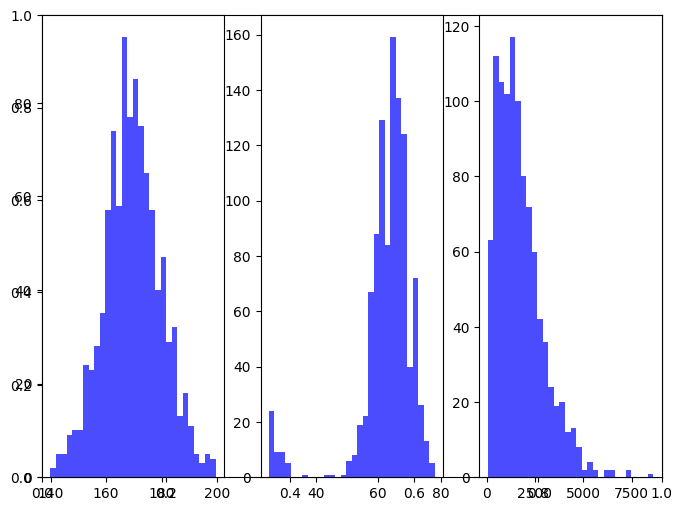

In [ ]:
plt.subplots(figsize=(8, 6))
plt.subplot(131)
plt.hist(dados_altura, bins = 30, alpha=0.7, color='blue')
plt.subplot(132)
plt.hist(dados_idade, bins = 30, alpha=0.7, color='blue')
plt.subplot(133)
plt.hist(dados_lampada, bins = 30, alpha=0.7, color='blue')

In [ ]:
def CalculaMedia(dados, coluna, n, qtd):
  media = [dados[coluna].sample(n, replace=True).mean() for _ in range(qtd)]
  return media

In [ ]:
n = 100
qtd = 10000

media_altura = CalculaMedia(dados_altura, 'alturas', n, qtd)
media_idade = CalculaMedia(dados_idade, 'idade', n, qtd)
media_lampada = CalculaMedia(dados_lampada, 'duracao', n, qtd)

In [ ]:
print("Média da idade população é: ", dados_idade['idade'].mean())
print("Média da altura população é: ", dados_altura['alturas'].mean())
print("Média da duração das lampadas da população é: ", dados_lampada['duracao'].mean())


Média da idade população é:  62.70857142857143
Média da altura população é:  169.52022
Média da duração das lampadas da população é:  1731.8036029420002


In [ ]:
def media(medias):
  return sum(medias) / len(medias)

  print("Médias amostrais")

print("Média da idade população é: ", media(media_idade))
print("Média da altura população é: ", media(media_altura))
print("Média da duração das lampadas da população é: ", media(media_lampada))


Média da idade população é:  62.72143999999978
Média da altura população é:  169.50991743000074
Média da duração das lampadas da população é:  1731.295038331834


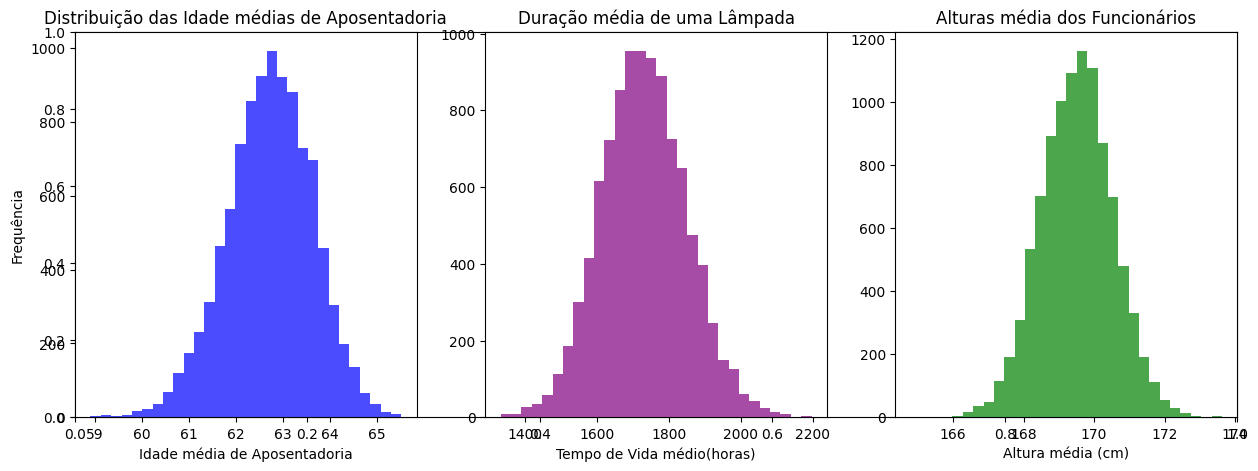

In [ ]:
plt.subplots(figsize=(15, 5))
plt.subplot(131)
plt.title('Distribuição das Idade médias de Aposentadoria')
plt.xlabel('Idade média de Aposentadoria')
plt.ylabel('Frequência')
plt.hist(media_idade, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(media_lampada, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')

plt.subplot(133)
plt.hist(media_altura, bins=30, alpha=0.7, color='green')
plt.title('Alturas média dos Funcionários')
plt.xlabel('Altura média (cm)')

plt.show()

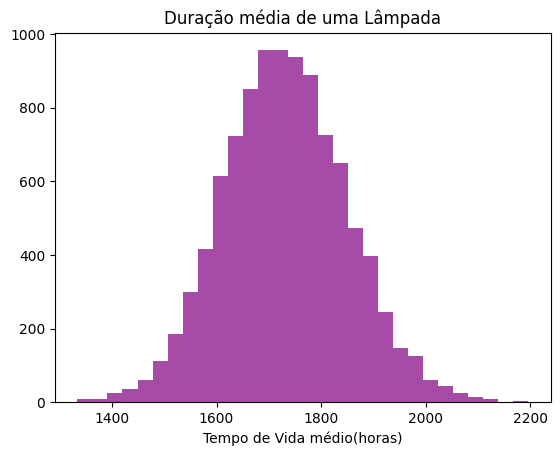

In [ ]:
# média da nova amostra
media_nova_amostra = 1200

media_duracao = dados_lampada['duracao'].mean()

# Quão distante essa média está do comportamento?

plt.hist(media_lampada, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [ ]:
duracao_amostras = pd.DataFrame({'media_duracao': media_lampada})
erro_padrao = duracao_amostras['media_duracao'].std()
print("Erro Padrão:", erro_padrao)
print("Média:", duracao_amostras['media_duracao'].mean())

Erro Padrão: 118.14996038439963
Média: 1731.2950383318291


In [ ]:
media_duracao - 3*erro_padrao # 3 desvios

np.float64(1377.3537217888013)

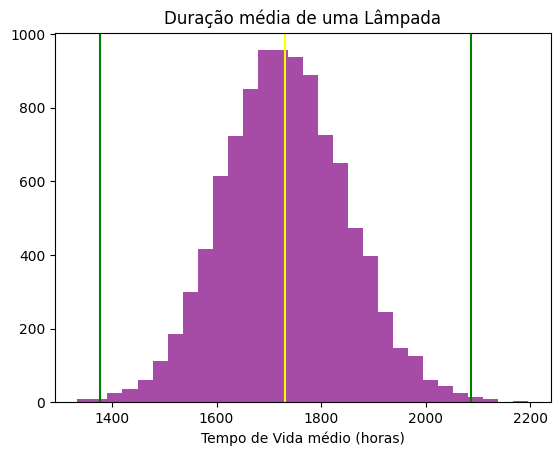

In [ ]:
# Visualizando a quantidade de amostras entre 3EP +- da média.

plt.hist(media_lampada, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio (horas)')
plt.axvline(media_duracao, color = "yellow")
plt.axvline(media_duracao + 3*erro_padrao , color = "green")
plt.axvline(media_duracao - 3*erro_padrao , color = "green")
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [ ]:
qnt_obs = duracao_amostras[(duracao_amostras > media_duracao - 3*erro_padrao) &
                          (duracao_amostras < media_duracao + 3*erro_padrao)]

In [ ]:
len(qnt_obs)

10000

In [ ]:
# quanto isso representa?
qnt_obs.count()/duracao_amostras.count()*100

,0
media_duracao,99.66


In [ ]:
desvio_padrao = duracao_amostras['media_duracao'].std()
desvio_padrao

118.14996038439963

In [ ]:
tamanho_amostra = len(duracao_amostras)
erro_padrao = media_duracao / np.sqrt(tamanho_amostra)
erro_padrao

np.float64(17.318036029420004)

In [ ]:
# levar em consideração essa amostra
dados_lampada

# nível de confiança definido
confianca = 0.95

In [ ]:
intervalo_confianca = stats.norm.interval(confianca,
                                          loc=media_duracao,
                                          scale=erro_padrao)

In [ ]:
print("IC (95%):", intervalo_confianca)

IC (95%): (np.float64(1697.86087604137), np.float64(1765.7463298426305))


Teste

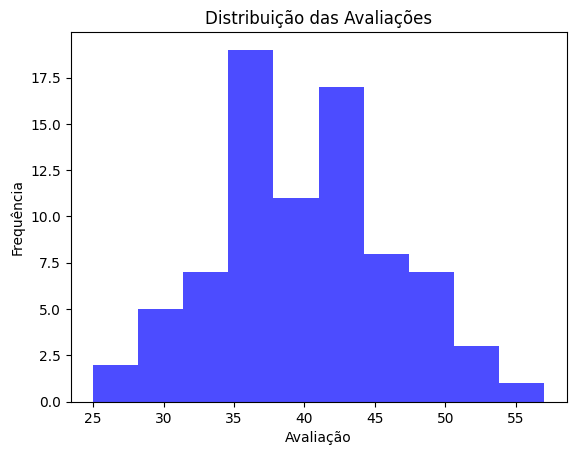

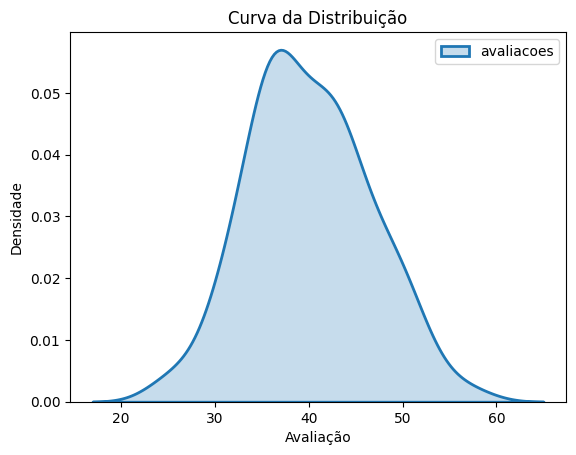

Conf (90%) (np.float64(38.84402439920928), np.float64(41.205975600790715))
Conf (95%) (np.float64(38.617780776207844), np.float64(41.43221922379215))
Média Amostral: 40.025
Intervalo de confiança (95.0%): (np.float64(28.592780776207846), np.float64(31.407219223792154))
Z-test: 13.96274198988354 p-value: 2.6311293593122384e-44
Conclusão: Rejeitar a hipótese nula


In [ ]:
import numpy as np
import scipy.stats as stats

# Conjunto de dados TechTaste
df_techtaste = pd.DataFrame({'avaliacoes': [38, 44, 33, 42, 47, 33, 36, 39, 42, 36, 39, 34, 42, 42, 36, 43, 31, 35, 36, 41, 42, 30, 25, 38, 47, 36, 32, 45, 44, 45, 37, 48, 37, 36, 44, 49, 31, 45, 45, 40, 36, 50, 38, 34, 36, 42, 46, 49, 36, 34, 38, 31, 53, 40, 57, 40, 36, 42, 26, 50, 32, 43, 35, 37, 42, 30, 36, 43, 40, 43, 44, 52, 37, 51, 35, 47, 40, 50, 37, 49]})

# Calculando o desvio padrão
desv_tech = df_techtaste.std()

# Calculando o erro padrão
erro_tech = stats.sem(df_techtaste['avaliacoes'])

# Histograma da distribuição
plt.hist(df_techtaste, bins=10, alpha=0.7, color='blue')
plt.title('Distribuição das Avaliações')
plt.xlabel('Avaliação')
plt.ylabel('Frequência')
plt.show()

# Curva da distribuição
sns.kdeplot(df_techtaste, color='blue', fill=True, linewidth=2)
plt.title('Curva da Distribuição')
plt.xlabel('Avaliação')
plt.ylabel('Densidade')
plt.show()

# Nível de confiança
conf = 0.90
intervalo_confianca_90 = stats.norm.interval(conf,
                                          loc=df_techtaste['avaliacoes'].mean(),
                                          scale=erro_tech
                                          )
intervalo_confianca_90

conf2 = 0.95
intervalo_confianca_95 = stats.norm.interval(conf2,
                                          loc=df_techtaste['avaliacoes'].mean(),
                                          scale=erro_tech
                                          )
intervalo_confianca_95

print("Conf (90%)", intervalo_confianca_90)

print("Conf (95%)", intervalo_confianca_95)

media_amostral = df_techtaste['avaliacoes'].mean()
print("Média Amostral:", media_amostral)

confianca = 0.95
tamanho = len(df_techtaste)
h0 = 30

intervalo_confianca = stats.norm.interval(confianca,
                                          loc=h0,
                                          scale=erro_tech)

print(f'Intervalo de confiança ({confianca*100}%): {intervalo_confianca}')

z_score, p_value = sm.stats.ztest(df_techtaste['avaliacoes'], value=h0, alternative='two-sided')
print("Z-test:", z_score, "p-value:", p_value)

nivel_significancia = 0.05

if p_value < nivel_significancia:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeita a hipótese nula'

print('Conclusão:', conclusao)

In [ ]:
# Dados
lampada_natalina = pd.read_csv("/content/experimento_lampadas_natalinas.csv")

h0 = 1570
confianca = 0.95
desvio = 105
tamanho = len(lampada_natalina['duracao'])

lampada_natalina['duracao'].mean()

intervalo = stats.norm.interval(confianca,
                                loc=h0,
                                scale=desvio/np.sqrt(tamanho))
print("H0:", h0)
print("Média:", lampada_natalina['duracao'].mean())
print("IC (95%):", intervalo)

H0: 1570
Média: 1529.5081310675512
IC (95%): (np.float64(1549.4203781623294), np.float64(1590.5796218376706))


In [ ]:
stats, p_valor = sm.stats.ztest(lampada_natalina['duracao'], value=h0, alternative='two-sided')
print("Z-test:", stats, "p-value:", p_valor)

# verifica a hipótese nula com base no valor-p

if p_valor < 0.05:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

print("Conclusão:", conclusao)

Z-test: -45.732770207263556 p-value: 0.0
Conclusão: Rejeitar a hipótese nula


In [ ]:
media_observada = lampada_natalina['duracao'].mean()
h0 = 1570
desvio_padrao = 105
raiz_tamanho_amostra = np.sqrt(len(lampada_natalina['duracao']))
erro_padrao = desvio_padrao / raiz_tamanho_amostra

z = (media_observada - h0) / erro_padrao
print("Valor de Z:", z)

Valor de Z: -3.856368469757031


In [ ]:
from scipy import stats

# Tempo de resposta em minutos para 25 solicitações de suporte
tempo_resposta = [28, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 24, 29, 30]

print("Média:",np.mean(tempo_resposta))
print("Desvio Padrão:", np.std(tempo_resposta))
print("Erro Padrão:", stats.sem(tempo_resposta))

stats, p_valor = stats.ttest_1samp(tempo_resposta, 30, alternative="less")
print("Z-test:", stats, "p-value:", p_valor)

if p_valor < 0.05:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeita a hipótese nula'

print('Conclusão:', conclusao)

Média: 29.96
Desvio Padrão: 1.8650469162999626
Erro Padrão: 0.38070110760717957
Z-test: -0.10506930292746224 p-value: 0.4585970095667924
Conclusão: Não rejeita a hipótese nula


In [ ]:
# Z-Test ou Z-Score é utilizado quando há mais de 30 amostras, e o
# desvio padrão da população é conhecido
# a amostra é aleatória e as observações são independentes

# o T-Test é utilizado quando há menos de 30 amostras, o desvio padrão
# é desconhecido e
# a amostra é aleatória e as observações são independentes

# T test 1 amostra: testa a hipótese sobre uma média amostral
# T test 2 amostras: testa a hipótese sobre a diferença entre as médias
# de duas amostras.
# T test duas amostras pareadas (relacionadas): investiga a hipótese
# sobre a média de uma amostra testada duas vezes.

Teste

In [ ]:
from scipy import stats

# Conjunto de dados Techsafe
df_techsafe = pd.DataFrame({'porcentagem_compressao': [21.99342831, 20.7234714 , 22.29537708, 24.04605971, 20.53169325, 20.53172609, 24.15842563, 22.53486946, 20.06105123, 22.08512009, 20.07316461, 20.06854049, 21.48392454, 17.17343951, 17.55016433, 19.87542494, 18.97433776, 21.62849467, 19.18395185, 18.1753926, 23.93129754, 20.5484474 , 21.13505641, 18.15050363, 19.91123455]})

media = np.mean(df_techsafe)
desvio = np.std(df_techsafe)
erro = stats.sem(df_techsafe)
h0 = 20
nivel_confianca = 0.95
nivel_significancia = 1-nivel_confianca

intervalo_confianca = stats.norm.interval(nivel_confianca,
                                          loc=h0,
                                          scale=erro
                                          )

t_test, p_value = stats.ttest_1samp(df_techsafe, h0, alternative='greater')

print("T-test:", t_test, "p-value:", p_value)
print("Média:", media)
print("IC (95%):", intervalo_confianca)
print("H0:", h0)
print("Nível significância:", nivel_significancia)
print("T-test", t_test)
print("P-valor", p_value)
if p_value < nivel_significancia:
    decisao = 'Rejeitar a hipótese nula'
else:
    decisao = 'Não rejeitar a hipótese nula'

print(f'Decisão: {decisao}')

T-test: [1.75887757] p-value: [0.045672]
Média: 20.6729838832
IC (95%): (array([19.25007619]), array([20.74992381]))
H0: 20
Nível significância: 0.050000000000000044
T-test [1.75887757]
P-valor [0.045672]
Decisão: Rejeitar a hipótese nula


Teste T com duas amostras independentes

286.4832
286.2498


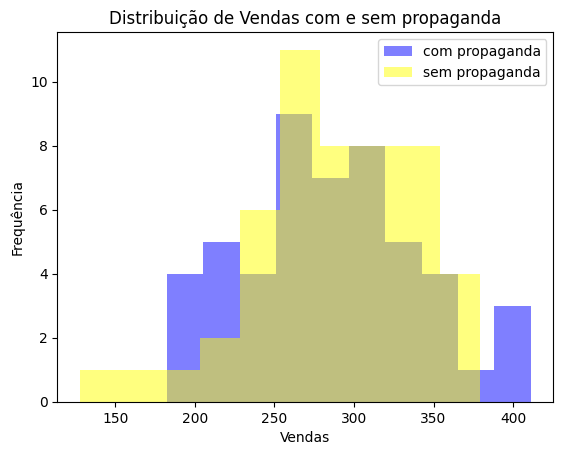

T-statistic: 0.021471690993471577
P-value: 0.9829130430622159
Decisão: Não rejeitar a hipótese nula


In [ ]:
vendas_com_propaganda = [329.80, 291.70, 338.86, 391.38, 285.95, 285.95, 394.75, 346.05, 271.83, 332.55, 272.19, 272.06, 314.52, 185.20, 196.50, 266.26, 239.23, 318.85, 245.52, 215.26, 387.94, 286.45, 304.05, 214.52, 267.34, 306.66, 230.94, 322.54, 263.96, 282.50, 263.90, 411.14, 299.19, 236.54, 349.35, 226.75, 312.53, 182.42, 220.31, 311.81, 344.31, 310.28, 293.66, 281.93, 211.29, 256.81, 272.36, 363.43, 320.62, 194.22]
vendas_sem_propaganda = [304.44, 261.89, 244.38, 321.70, 346.86, 348.08, 234.65, 266.45, 304.88, 343.53, 256.25, 273.86, 218.62, 213.23, 333.75, 366.37, 280.68, 345.21, 306.70, 246.29, 306.68, 377.28, 282.85, 378.88, 127.82, 334.31, 290.22, 267.06, 290.51, 165.74, 271.82, 306.43, 373.67, 253.90, 236.49, 254.89, 339.92, 304.73, 253.21, 315.80, 292.80, 343.12, 242.88, 265.34, 261.47, 197.19, 302.77, 300.66, 285.31, 270.92]

print(np.mean(vendas_com_propaganda))

print(np.mean(vendas_sem_propaganda))

plt.hist(vendas_com_propaganda, color='blue', alpha=0.5, label="com propaganda")
plt.hist(vendas_sem_propaganda, color='yellow', alpha=0.5, label="sem propaganda")

plt.xlabel('Vendas')
plt.ylabel('Frequência')
plt.title('Distribuição de Vendas com e sem propaganda')
plt.legend()
plt.show()

from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(vendas_com_propaganda, vendas_sem_propaganda)
print("T-statistic:", t_statistic)
print("P-value:", p_value)

nivel_significancia=0.05

if p_valor < nivel_significancia:
    decisao = 'Rejeitar a hipótese nula'
else:
    decisao = 'Não rejeitar a hipótese nula'

print(f'Decisão: {decisao}')

In [ ]:
t_duas_amostras_independentes_vaf =
 (média_amostra_1 - média_amostra_2) / np.sqrt((desvio_amostra_1 / len(df_amostra_1) + (desvio_amostra_2 / len(df_amostra_2))))

Teste T com duas amostras dependentes entre a coleta A e a coleta B.

In [ ]:
antes_do_treinamento = [78, 65, 75, 80, 85, 88, 79, 81, 76, 84]
apos_o_treinamento = [85, 70, 75, 87, 90, 92, 84, 82, 76, 91]
# Comparando antes e depois
resultado_subtracao = [b - a for a, b in zip(antes_do_treinamento,apos_o_treinamento)]
print(f'Resultado da diferença entre A e B: {resultado_subtracao}')

from scipy.stats import ttest_rel
t_statistic, p_value = ttest_rel(apos_o_treinamento, antes_do_treinamento, alternative="greater")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

Resultado da diferença entre A e B: [7, 5, 0, 7, 5, 4, 5, 1, 0, 7]
T-statistic: 4.619361962060379
P-value: 0.000627744161772394


In [ ]:
import pandas as pd

df_equipe_vendas = pd.DataFrame({'Vendedor': [ 'Luíza', 'Bia', 'Rodrigo', 'Allan', 'Evaldo'],
                                 'Vendas Antes (R$)': [252.72, 203.91, 307.32, 185.78, 220.5],
                                 'Vendas Depois (R$)': [285.1, 223.15, 324.41, 202.23, 240.63]})

from scipy.stats import ttest_rel

stat, p_valor = ttest_rel(df_equipe_vendas['Vendas Depois (R$)'], df_equipe_vendas['Vendas Antes (R$)'])
print(f'Estatística do teste t pareado: {stat}')
print(f'Valor-p: {p_valor}')

nivel_significancia = 0.05
if p_valor < nivel_significancia:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeitar a hipótese nula'

print('Conclusão:', conclusao)

Estatística do teste t pareado: 7.23705258430516
Valor-p: 0.0019344230773580572


In [ ]:
import pandas as pd

df_filiais = pd.DataFrame({'Filial Centro-Norte': [3.2, 2.9, 2.0, 3.3, 3.1],
                           'Filial Sul': [3.8, 4.0, 4.7, 4.9, 4.8]})

from scipy.stats import ttest_ind

stat, p_valor = ttest_ind(df_filiais['Filial Centro-Norte'], df_filiais['Filial Sul'])

print(f'Estatística do teste t independente: {stat}')
print(f'Valor-p: {p_valor}')

nivel_significancia = 0.05
if p_valor < nivel_significancia:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeitar a hipótese nula'

print('Conclusão:', conclusao)

Estatística do teste t independente: -4.73902240270431
Valor-p: 0.001465798816319686
Conclusão: Rejeitar a hipótese nula


Teste Mann-Whitney (não paramétrico) para comparação entre duas variáveis quando a variável A não representa as mesmas unidades de coleta que a variável B.



In [ ]:
# Dados de desempenho dos dois grupos
treino_a = [5, 3, 8, 4, 6]
treino_b = [4, 2, 7, 5, 3]

# Importando teste mannwhitneyu
from scipy.stats import mannwhitneyu

# Aplicando o teste de Mann-Whitney
# Aplicando o teste de Mann-Whitney
stats, p_valor = mannwhitneyu (treino_a, treino_b, alternative = "two-sided")
print(p_valor)

0.4605966187047713


Teste Qui-Quadrado para associações entre variáveis categóricas

In [ ]:
import pandas as pd

# Dados do exemplo
df = pd.DataFrame({'Desempenho': {0: 'Regular', 1: 'Bom', 2: 'Bom', 3: 'Excelente', 4: 'Bom', 5: 'Bom', 6: 'Regular', 7: 'Regular', 8: 'Excelente', 9: 'Ruim', 10: 'Bom', 11: 'Regular', 12: 'Muito Bom', 13: 'Bom', 14: 'Bom', 15: 'Regular', 16: 'Muito Bom', 17: 'Bom', 18: 'Muito Bom', 19: 'Excelente', 20: 'Ruim', 21: 'Excelente', 22: 'Ruim', 23: 'Ruim', 24: 'Regular', 25: 'Excelente', 26: 'Ruim', 27: 'Excelente', 28: 'Excelente', 29: 'Regular', 30: 'Regular', 31: 'Ruim', 32: 'Regular', 33: 'Regular', 34: 'Muito Bom', 35: 'Excelente', 36: 'Regular', 37: 'Excelente', 38: 'Excelente', 39: 'Muito Bom', 40: 'Ruim', 41: 'Ruim', 42: 'Ruim', 43: 'Ruim', 44: 'Muito Bom', 45: 'Regular', 46: 'Excelente', 47: 'Muito Bom', 48: 'Muito Bom', 49: 'Muito Bom', 50: 'Muito Bom', 51: 'Muito Bom', 52: 'Bom', 53: 'Ruim', 54: 'Muito Bom', 55: 'Bom', 56: 'Bom', 57: 'Excelente', 58: 'Bom', 59: 'Muito Bom'},
                   'Metodo_Ensino': {0: 'Moderno', 1: 'Tradicional', 2: 'Tradicional', 3: 'Moderno', 4: 'Moderno', 5: 'Moderno', 6: 'Moderno', 7: 'Moderno', 8: 'Moderno', 9: 'Tradicional', 10: 'Tradicional', 11: 'Moderno', 12: 'Tradicional', 13: 'Moderno', 14: 'Tradicional', 15: 'Tradicional', 16: 'Moderno', 17: 'Moderno', 18: 'Tradicional', 19: 'Tradicional', 20: 'Moderno', 21: 'Tradicional', 22: 'Moderno', 23: 'Moderno', 24: 'Tradicional', 25: 'Tradicional', 26: 'Moderno', 27: 'Moderno', 28: 'Moderno', 29: 'Moderno', 30: 'Moderno', 31: 'Moderno', 32: 'Tradicional', 33: 'Moderno', 34: 'Tradicional', 35: 'Tradicional', 36: 'Tradicional', 37: 'Moderno', 38: 'Tradicional', 39: 'Moderno', 40: 'Tradicional', 41: 'Moderno', 42: 'Tradicional', 43: 'Moderno', 44: 'Moderno', 45: 'Moderno', 46: 'Moderno', 47: 'Moderno', 48: 'Moderno', 49: 'Tradicional', 50: 'Moderno', 51: 'Moderno', 52: 'Moderno', 53: 'Moderno', 54: 'Tradicional', 55: 'Moderno', 56: 'Moderno', 57: 'Tradicional', 58: 'Moderno', 59: 'Tradicional'}})

# Tabela de contingência
tab_contingencia = pd.crosstab(df['Desempenho'], df['Metodo_Ensino'])

from scipy.stats import chi2_contingency

chi2, p_valor, _, _ = chi2_contingency(tab_contingencia)

# Resultados iniciais
print(f'Estatística chi2: {chi2}')
print(f'p-valor: {p_valor}')

# Tomada de decisão
nivel_significancia = 0.05
if p_valor < nivel_significancia:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeitar a hipótese nula'

print('Conclusão:', conclusao)

Estatística chi2: 1.850394024307068
p-valor: 0.7632507187470916
Conclusão: Não rejeitar a hipótese nula


Teste de Wilcoxon para comparação entre variáveis pareadas com uso de mediana

In [ ]:
# Preferências dos consumidores antes e depois da mudança no layout
preferencias_antes = [4, 2, 5, 2, 5, 6, 7, 8, 9, 10 ]
preferencias_depois = [8, 5, 3, 5, 8, 9, 9, 9, 10, 9]
#diferenças de percepção
resultado_subtracao = [b - a for a, b in zip(preferencias_antes,preferencias_depois)]
print("Média:",np.mean(resultado_subtracao))
print("Média:",np.median(resultado_subtracao))

from scipy.stats import wilcoxon
stats, p_valor = wilcoxon(preferencias_depois, preferencias_antes, alternative="greater")
print(p_valor)
nivel_significancia=0.05

if p_valor < nivel_significancia:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"
conclusao

Média: 1.7
Média: 2.5
0.015625


'Rejeitar a hipótese nula'

In [ ]:
import pandas as pd

df_avaliacoes = pd.DataFrame({
    'playcatch': [4, 5, 3, 4, 5, 4, 4, 3, 5, 4, 5, 3, 4],
    'concorrente': [3, 4, 3, 3, 2, 4, 3, 2, 3, 3, 4, 2, 3]
})
# H0 = Não há diferença
# H1 = Há diferença

from scipy.stats import mannwhitneyu

stat, p_valor = mannwhitneyu(df_avaliacoes['playcatch'], df_avaliacoes['concorrente'], alternative='two-sided')
print(f'Estatística do teste de mannwhitneyu: {stat}')
print(f'Valor-p: {p_valor}')

nivel_significancia = 0.05
if p_valor < nivel_significancia:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = "Não rejeita a hipótese nula"
conclusao

Estatística do teste de mannwhitneyu: 140.5
Valor-p: 0.0026661275820288304


'Rejeitar a hipótese nula'

In [ ]:
import pandas as pd

df_wt = pd.DataFrame({
    'Antes_WatchTogether': [3, 4, 3, 4, 2, 4, 3, 2, 3, 3, 4, 2, 3],
    'Depois_WatchTogether': [4, 5, 3, 4, 5, 4, 4, 3, 5, 4, 5, 3, 4]
})

df_wt

from scipy.stats import wilcoxon

stat, p_valor = wilcoxon(df_wt['Depois_WatchTogether'] - df_wt['Antes_WatchTogether'])

print(f'Estatística do teste de Wilcoxon: {stat}')
print(f'Valor-p: {p_valor}')

nivel_significancia = 0.05
if p_valor < nivel_significancia:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeitar a hipótese nula'

print('Conclusão:', conclusao)

Estatística do teste de Wilcoxon: 0.0
Valor-p: 0.001953125
Conclusão: Rejeitar a hipótese nula
